# Minería de reglas de asociación 

In [202]:
from pathlib import Path
import csv
import random

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules , fpgrowth

Machine Learning Extensions: mlxtend es una Biblioteca que trae funciones adicionales para ciencia de datos y aprendizaje automático que no siempre vienen directamente en scikit-learn.

## Antes de empezar: ideas clave

En minería de reglas de asociación se trabaja con transacciones. Cada transacción contiene un conjunto de artículos comprados juntos.

Ejemplo:

- T1 = [pan, leche]
- T2 = [pan, pañales, cerveza, huevos]
- T3 = [leche, pañales, cerveza, refresco]

A partir de esas transacciones buscamos patrones del tipo:

**{A} -> {B}** : **cuando aparece A, suele aparecer también B**

Recordando ...

## 1. Soporte

Mide qué proporción de transacciones contiene el conjunto de ítems \(A\).

$$
support(A)=\frac{\text{número de transacciones que contienen } A}{\text{número total de transacciones}}
$$

## 2. Confianza

Mide qué tan frecuentemente aparece el consecuente cuando ya apareció el antecedente.

$$
confidence(A \rightarrow B)=\frac{support(A \cup B)}{support(A)}
$$

## 3. Lift

Mide si la relación entre antecedente y consecuente es mayor a la esperada por azar.

$$
lift(A \rightarrow B)=\frac{confidence(A \rightarrow B)}{support(B)}
$$

Interpretación básica del lift:

- **lift > 1**: asociación positiva
- **lift = 1**: independencia aproximada
- **lift < 1**: asociación negativa o poco interesante

## Ejemplo 01

Se tienen las siguientes transacciones:

`T1 = {pan, leche}`  
`T2 = {pan, pañales, cerveza, huevos}`  
`T3 = {leche, pañales, cerveza, refresco de cola}`  
`T4 = {pan, leche, pañales, cerveza}`  
`T5 = {pan, leche, pañales, refresco de cola}`

Obtenciòn de la siguiente regla:

`{pañales} -> {cerveza}`

In [203]:
transacciones = [
    ["pan", "leche"],
    ["pan", "pañales", "cerveza", "huevos"],
    ["leche", "pañales", "cerveza", "refresco"],
    ["pan", "leche", "pañales", "cerveza"],
    ["pan", "leche", "pañales", "refresco"],
]

codificador = TransactionEncoder()
arreglo = codificador.fit(transacciones).transform(transacciones)
matriz_binaria = pd.DataFrame(arreglo, columns=codificador.columns_)

print("Matriz:")
matriz_binaria

Matriz:


,cerveza,huevos,leche,pan,pañales,refresco
0,False,False,True,True,False,False
1,True,True,False,True,True,False
2,True,False,True,False,True,True
3,True,False,True,True,True,False
4,False,False,True,True,True,True


In [204]:
soporte_items = matriz_binaria.mean(axis=0).sort_values(ascending=False).rename("soporte") #
conteo_items = matriz_binaria.sum(axis=0).sort_values(ascending=False).rename("cuantos")

resumen = pd.concat([conteo_items, soporte_items], axis=1)
print("Soporte de artículos individuales:")
resumen

Soporte de artículos individuales:


,cuantos,soporte
pan,4,0.8
leche,4,0.8
pañales,4,0.8
cerveza,3,0.6
refresco,2,0.4
huevos,1,0.2


### Cálculo la regla `{pañales} -> {cerveza}`



- `pañales` aparece en `T2`, `T3`, `T4` y `T5` -> 4 transacciones
- `cerveza` aparece en `T2`, `T3` y `T4` -> 3 transacciones
- `{pañales, cerveza}` aparece en `T2`, `T3` y `T4` -> 3 transacciones

Como tenemos `5` transacciones en total:

- `soporte(pañales) = 4 / 5 = 0.80`
- `soporte(cerveza) = 3 / 5 = 0.60`
- `soporte({pañales, cerveza}) = 3 / 5 = 0.60`

Entonces:

- `confianza({pañales} -> {cerveza}) = 0.60 / 0.80 = 0.75`
- `lift({pañales} -> {cerveza}) = 0.75 / 0.60 = 1.25`

Interpretación:

- La confianza es `0.75`, así que el `75%` de las veces que aparece `pañales`, también aparece `cerveza`.
- El lift es `1.25`, por lo que la relación es más fuerte que una coincidencia al azar.

In [205]:
total_transacciones = len(matriz_binaria)

soporte_pañales = matriz_binaria["pañales"].mean()
soporte_cerveza = matriz_binaria["cerveza"].mean()
#axis = 1: Indica que va a revisar las filas , 
# Revisión de filas donde aparece tanto pañales como cervezas
soporte_pañales_cerveza = matriz_binaria[["pañales", "cerveza"]].all(axis=1).mean()
confianza_pañales_a_cerveza = soporte_pañales_cerveza / soporte_pañales
lift_pañales_a_cerveza = confianza_pañales_a_cerveza / soporte_cerveza

resumen_regla_manual = pd.DataFrame({
    "metrica": [
        "soporte(pañales)",
        "soporte(cerveza)",
        "soporte(pañales ∪ cerveza)",
        "confianza(pañales -> cerveza)",
        "lift(pañales -> cerveza)"
    ],
    "valor": [
        soporte_pañales,
        soporte_cerveza,
        soporte_pañales_cerveza,
        confianza_pañales_a_cerveza,
        lift_pañales_a_cerveza
    ]
})

resumen_regla_manual

,metrica,valor
0,soporte(pañales),0.80
1,soporte(cerveza),0.60
2,soporte(pañales ∪ cerveza),0.60
3,confianza(pañales -> cerveza),0.75
4,lift(pañales -> cerveza),1.25


Reglas de asociacion para el dataset  `Groceries`.

## 1.  Archivo Groceries

EL archivo groceries contiene 30 días de ventas reales de un comercio local

In [206]:
ruta_archivo = Path("./data/raw/groceries_transactions.csv")

transacciones = []

with open(ruta_archivo, "r", encoding="utf-8") as archivo:
    lector = csv.reader(archivo)
    for fila in lector:
        articulos = [articulo.strip().strip('"') for articulo in fila if articulo.strip()]
        articulos = list(dict.fromkeys(articulos))  # Eliminar duplicados dentro de la transacción, 
        if articulos:
            transacciones.append(articulos)

print("Número de transacciones:" , len(transacciones))
print("Primera transacción:" , transacciones[0])


Número de transacciones: 9835
Primera transacción: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']


## 2. Conversión a matriz binaria

- `True` o `1` si el artículo aparece en la transacción
- `False` o `0` si no aparece


In [207]:
codificador = TransactionEncoder()
# El codificador revisa todas las transacciones para identificar qué productos aparecen.
# Después transforma cada compra en una fila binaria
arreglo_codificado = codificador.fit(transacciones).transform(transacciones)
datos_binarios = pd.DataFrame(arreglo_codificado, columns=codificador.columns_)
datos_binarios

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9833,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [208]:
#Imprimir las dimensiones de una matriz
print(datos_binarios.shape)
numero_transacciones = len(datos_binarios)

numero_articulos = datos_binarios.shape[1]
proporcion_de_unos = datos_binarios.to_numpy().mean()

print("Transacciones:", numero_transacciones)
print("Artículos distintos:", numero_articulos)
print("Porcentaje de presencia:", round(proporcion_de_unos, 6))

(9835, 169)
Transacciones: 9835
Artículos distintos: 169
Porcentaje de presencia: 0.026091


2.61% de todas las celdas de la matriz binaria son 1,

## 3. Exploración  del dataset


In [209]:
#x = 0: indica que va a realizar una suma por cada columna; es decir cada columna representa un producto
frecuencia_absoluta = datos_binarios.sum(axis=0).sort_values(ascending=False)
frecuencia_relativa = datos_binarios.mean(axis=0).sort_values(ascending=False)

resumen_articulos = pd.DataFrame({
    "frecuencia_absoluta": frecuencia_absoluta,
    "frecuencia_relativa": frecuencia_relativa
})

print("Los 10 artículos más frecuentes son:")
resumen_articulos.head(10)

Los 10 artículos más frecuentes son:


,frecuencia_absoluta,frecuencia_relativa
whole milk,2513,0.255516
other vegetables,1903,0.193493
rolls/buns,1809,0.183935
soda,1715,0.174377
yogurt,1372,0.139502
bottled water,1087,0.110524
root vegetables,1072,0.108998
tropical fruit,1032,0.104931
shopping bags,969,0.098526
sausage,924,0.093950


## 4. Exploración de las primeras 5 transacciones


In [210]:
for indice, transaccion in enumerate(transacciones[0:5], start=1):
    print(f"[{indice}] {transaccion}")

[1] ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
[2] ['tropical fruit', 'yogurt', 'coffee']
[3] ['whole milk']
[4] ['pip fruit', 'yogurt', 'cream cheese', 'meat spreads']
[5] ['other vegetables', 'whole milk', 'condensed milk', 'long life bakery product']


## 5. Visualización de transacciones como matriz dispersa


In [211]:
def graficar_transacciones_dispersas(datos: pd.DataFrame, numero_filas: int = 15, titulo: str = ""):
    muestra = datos.iloc[:numero_filas]
    coordenadas_y, coordenadas_x = muestra.to_numpy().nonzero()

    plt.figure(figsize=(12, 4))
    plt.scatter(coordenadas_x, coordenadas_y, marker="s", s=20)
    plt.gca().invert_yaxis()
    plt.xlabel("Índice del artículo")
    plt.ylabel("Índice de la transacción")
    plt.title(titulo or f"Distribución de artículos en las primeras {numero_filas} transacciones")
    plt.show()

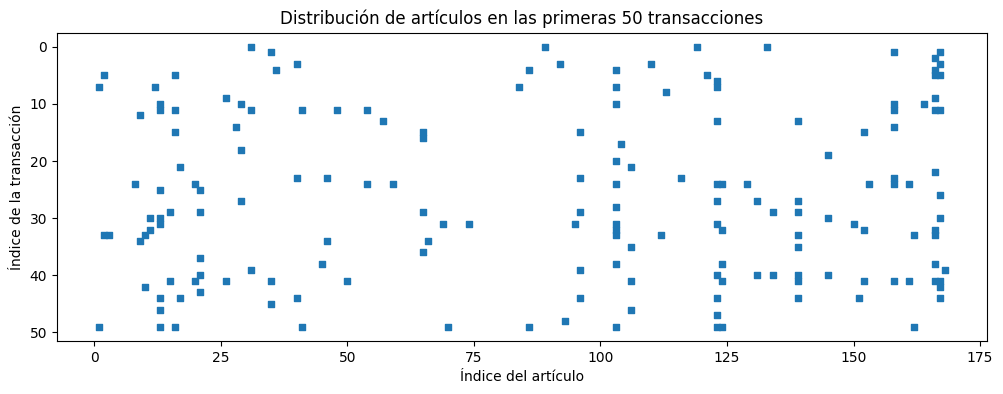

In [212]:
graficar_transacciones_dispersas(
    datos_binarios,
    numero_filas=50,
    titulo="Distribución de artículos en las primeras 50 transacciones"
)

In [213]:
def graficar_transacciones_con_nombres(datos: pd.DataFrame, numero_filas: int = 5, titulo: str = ""):
    muestra = datos.iloc[:numero_filas]

    articulos_presentes = muestra.columns[muestra.any(axis=0)]
    muestra_filtrada = muestra[articulos_presentes]

    coordenadas_y, coordenadas_x = muestra_filtrada.to_numpy().nonzero()

    plt.figure(figsize=(12, 4))
    plt.scatter(coordenadas_x, coordenadas_y, marker="s", s=80)
    plt.gca().invert_yaxis()

    plt.xticks(
        ticks=range(len(articulos_presentes)),
        labels=articulos_presentes,
        rotation=45,
        ha="right"
    )

    plt.yticks(range(numero_filas), [f"T{i+1}" for i in range(numero_filas)])
    plt.xlabel("Artículo")
    plt.ylabel("Transacción")
    plt.title(titulo or f"Artículos presentes en las primeras {numero_filas} transacciones")
    plt.tight_layout()
    plt.show()

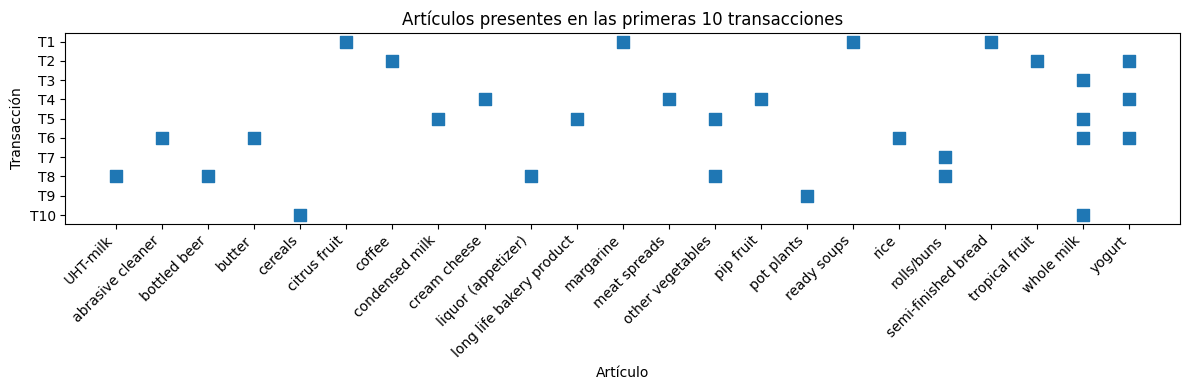

In [214]:
graficar_transacciones_con_nombres(
    datos=datos_binarios,
    numero_filas=10,
    titulo="Artículos presentes en las primeras 10 transacciones"
)

## 6. Muestra aleatoria de 100 transacciones


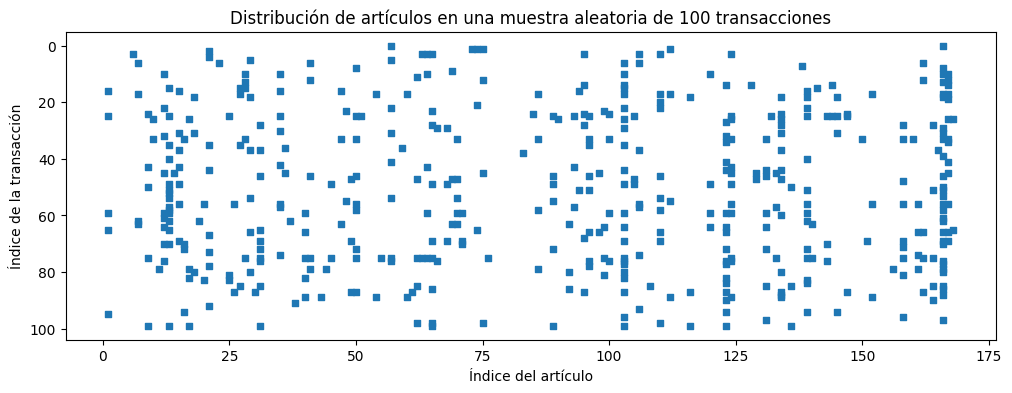

In [215]:
tamano_muestra = min(100, len(datos_binarios))
indices_muestra = random.sample(range(len(datos_binarios)), tamano_muestra)
datos_muestra = datos_binarios.iloc[indices_muestra].reset_index(drop=True)

graficar_transacciones_dispersas(
    datos_muestra,
    numero_filas=tamano_muestra,
    titulo="Distribución de artículos en una muestra aleatoria de 100 transacciones"
)

## 7. Tamaño de las transacciones


In [216]:
tamano_transacciones = datos_binarios.sum(axis=1) 
#axis 1 = suma por fila , axis = 0 ; suma pr columnas
tamano_transacciones.describe()

count    9835.000000
mean        4.409456
std         3.589385
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        32.000000
dtype: float64

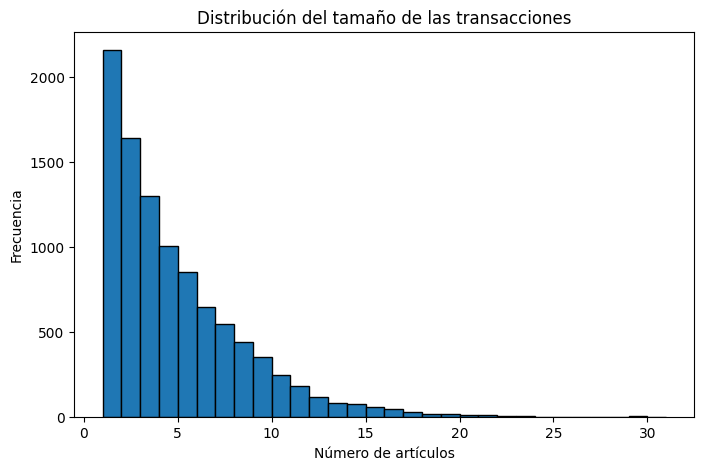

In [217]:
plt.figure(figsize=(8, 5))
plt.hist(tamano_transacciones, bins=range(1, int(tamano_transacciones.max()) ), edgecolor="black")
plt.title("Distribución del tamaño de las transacciones")
plt.xlabel("Número de artículos")
plt.ylabel("Frecuencia")
plt.show()

In [218]:
transacciones_32 = datos_binarios[tamano_transacciones == 32]
fila = transacciones_32.iloc[0]
articulos = fila[fila].index.tolist()

print("Cantidad de artículos:", len(articulos))
print(articulos)

Cantidad de artículos: 32
['beef', 'beverages', 'butter', 'candles', 'chicken', 'citrus fruit', 'cream cheese', 'curd', 'domestic eggs', 'flour', 'frankfurter', 'ham', 'hard cheese', 'hygiene articles', 'liver loaf', 'margarine', 'mayonnaise', 'other vegetables', 'pasta', 'roll products', 'rolls/buns', 'root vegetables', 'sausage', 'skin care', 'soft cheese', 'soups', 'specialty fat', 'sugar', 'tropical fruit', 'whipped/sour cream', 'whole milk', 'yogurt']


## 8. Frecuencia de artículos


In [219]:
print("Frecuencia relativa de los primeros 4 artículos:")
print(datos_binarios.iloc[:, :4].mean(axis=0))

print("\nTop 10 artículos por frecuencia absoluta:")
print(frecuencia_absoluta.head(10))

print("\nArtículos menos frecuentes:")
print(frecuencia_absoluta.tail(10))

Frecuencia relativa de los primeros 4 artículos:
Instant food products    0.008033
UHT-milk                 0.033452
abrasive cleaner         0.003559
artif. sweetener         0.003254
dtype: float64

Top 10 artículos por frecuencia absoluta:
whole milk          2513
other vegetables    1903
rolls/buns          1809
soda                1715
yogurt              1372
bottled water       1087
root vegetables     1072
tropical fruit      1032
shopping bags        969
sausage              924
dtype: int64

Artículos menos frecuentes:
make up remover          8
salad dressing           8
toilet cleaner           7
frozen chicken           6
baby cosmetics           6
bags                     4
kitchen utensil          4
preservation products    2
baby food                1
sound storage medium     1
dtype: int64


## 9. Gráficas de frecuencia


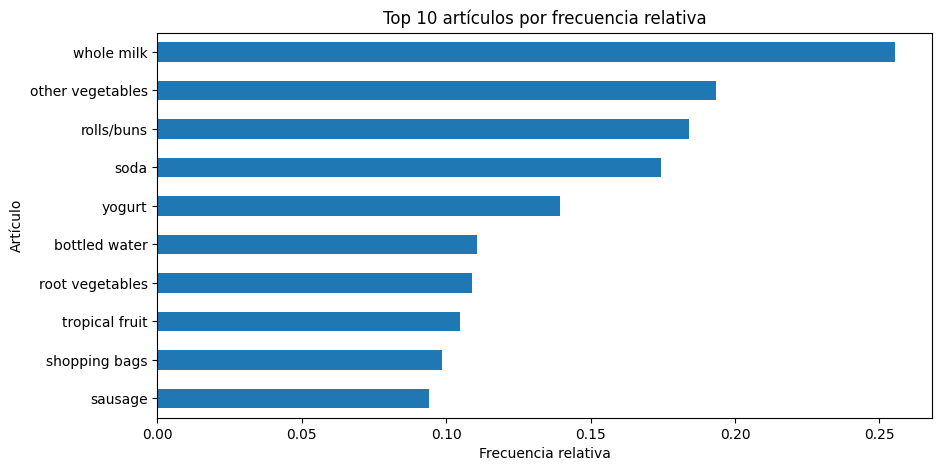

In [220]:
top_n = 10

plt.figure(figsize=(10, 5))
frecuencia_relativa.head(top_n).sort_values().plot(kind="barh")
plt.title("Top 10 artículos por frecuencia relativa")
plt.xlabel("Frecuencia relativa")
plt.ylabel("Artículo")
plt.show()

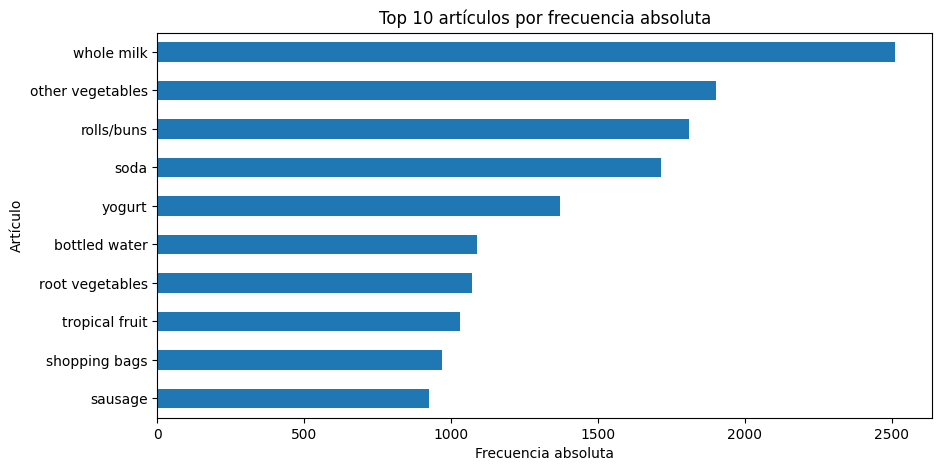

In [221]:
plt.figure(figsize=(10, 5))
frecuencia_absoluta.head(top_n).sort_values().plot(kind="barh")
plt.title("Top 10 artículos por frecuencia absoluta")
plt.xlabel("Frecuencia absoluta")
plt.ylabel("Artículo")
plt.show()

## 10. Artículos con soporte mayor o igual a 0.10


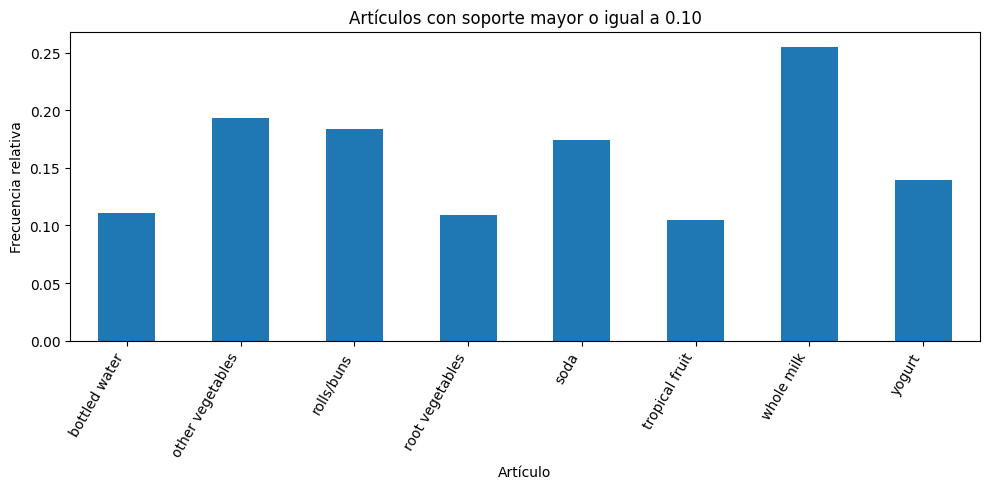

In [222]:
#los productos que aparecen en por lo menos el 10% de las transacciones
umbral_soporte = 0.1
articulos_soporte_10 = frecuencia_relativa[frecuencia_relativa >= umbral_soporte].sort_index()

plt.figure(figsize=(10, 5))
articulos_soporte_10.plot(kind="bar")
plt.title("Artículos con soporte mayor o igual a 0.10")
plt.xlabel("Artículo")
plt.ylabel("Frecuencia relativa")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

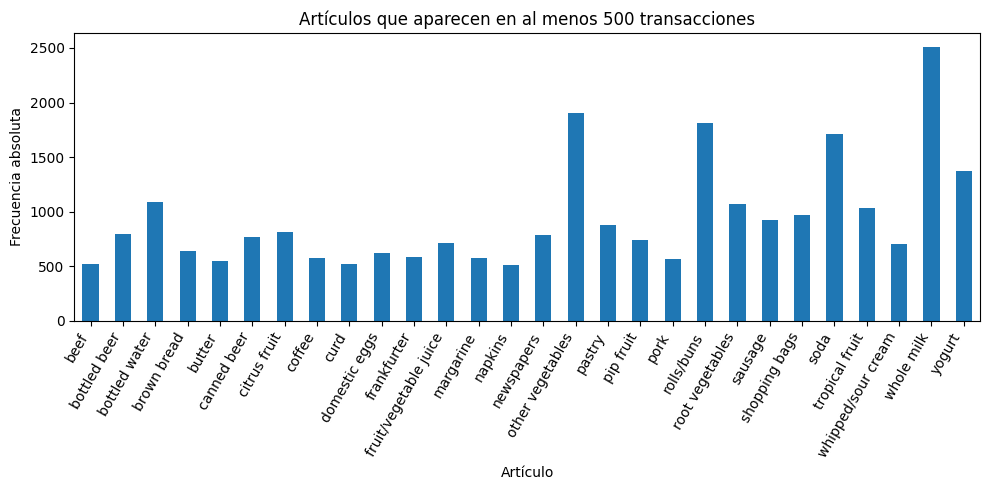

In [223]:
minimo_transacciones = 500
articulos_min = frecuencia_absoluta[frecuencia_absoluta >= minimo_transacciones].sort_index()

if articulos_min.empty:
    print("No hay artículos que aparezcan en al menos 500 transacciones.")
else:
    plt.figure(figsize=(10, 5))
    articulos_min.plot(kind="bar")
    plt.title("Artículos que aparecen en al menos 500 transacciones")
    plt.xlabel("Artículo")
    plt.ylabel("Frecuencia absoluta")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

## 12. Itemsets frecuentes con soporte mínimo de 0.05 y longitud mayor o igual a 2


In [224]:
itemsets_frecuentes_05 = apriori(datos_binarios, min_support=0.05, use_colnames=True)
itemsets_frecuentes_05["longitud"] = itemsets_frecuentes_05["itemsets"].apply(len)
itemsets_frecuentes_05["conteo"] = (itemsets_frecuentes_05["support"] * len(datos_binarios)).round().astype(int)

itemsets_frecuentes_05_filtrados = itemsets_frecuentes_05[itemsets_frecuentes_05["longitud"] >= 2]
itemsets_frecuentes_05_filtrados.sort_values("support", ascending=False).head(20)

,support,itemsets,longitud,conteo
28,0.074835,"frozenset({other vegetables, whole milk})",2,736
29,0.056634,"frozenset({whole milk, rolls/buns})",2,557
30,0.056024,"frozenset({yogurt, whole milk})",2,551


## 13. Limpieza de datos: eliminar transacciones con un solo artículo


In [225]:
mascara_mas_de_un_articulo = tamano_transacciones > 1
transacciones_limpias = [
    transacciones[i]
    for i in range(len(transacciones))
    if mascara_mas_de_un_articulo.iloc[i]
]

codificador_limpio = TransactionEncoder()
arreglo_limpio = codificador_limpio.fit(transacciones_limpias).transform(transacciones_limpias)
datos_limpios = pd.DataFrame(arreglo_limpio, columns=codificador_limpio.columns_)

print(f"Transacciones originales: {len(datos_binarios)}")
print(f"Transacciones con más de un artículo: {len(datos_limpios)}")

Transacciones originales: 9835
Transacciones con más de un artículo: 7676


## 14. Primer intento de reglas: soporte = 0.10 y confianza = 0.80



- soporte mínimo = 0.10
- confianza mínima = 0.80

En datasets reales esto puede producir muy pocas reglas o incluso ninguna, porque estamos pidiendo patrones muy frecuentes y además muy confiables.

In [226]:
itemsets_modelo_inicial = apriori(datos_limpios,
                                   min_support=0.10, 
                                   use_colnames=True)
print(itemsets_modelo_inicial)

reglas_iniciales = association_rules(itemsets_modelo_inicial,
                                    metric="confidence",
                                    min_threshold=0.80)

if not reglas_iniciales.empty:
    reglas_iniciales["longitud_regla"] = (
        reglas_iniciales["antecedents"].apply(len) + reglas_iniciales["consequents"].apply(len)
    )
    reglas_iniciales = reglas_iniciales[reglas_iniciales["longitud_regla"] >= 2].copy()

print(f"Número de reglas con soporte >= 0.10 y confianza >= 0.80: {len(reglas_iniciales)}")

if reglas_iniciales.empty:
    print("No se generaron reglas con estos valores")

     support                       itemsets
0   0.132882     frozenset({bottled water})
1   0.103960      frozenset({citrus fruit})
2   0.239838  frozenset({other vegetables})
3   0.109171            frozenset({pastry})
4   0.221470        frozenset({rolls/buns})
5   0.136399   frozenset({root vegetables})
6   0.117249           frozenset({sausage})
7   0.119984     frozenset({shopping bags})
8   0.203101              frozenset({soda})
9   0.131449    frozenset({tropical fruit})
10  0.311621        frozenset({whole milk})
11  0.173528            frozenset({yogurt})
Número de reglas con soporte >= 0.10 y confianza >= 0.80: 0
No se generaron reglas con estos valores


## 15. Modelo ajustado: soporte = 0.008 y confianza = 0.30


- soporte mínimo = 0.008
- confianza mínima = 0.30

Esto permite encontrar asociaciones menos frecuentes, pero todavía potencialmente útiles.

Nota importante: bajar mucho el soporte puede generar demasiadas reglas.  
Aplicar  métricas como `lift` y no quedarse solo con la confianza.

In [244]:
itemsets_modelo = apriori(datos_limpios, min_support=0.008, use_colnames=True)

print(len(itemsets_modelo))
reglas = association_rules(itemsets_modelo, metric="confidence", min_threshold=0.30)

if not reglas.empty:
    reglas["longitud_regla"] = (
        reglas["antecedents"].apply(len) + reglas["consequents"].apply(len)
    )
    reglas = reglas[reglas["longitud_regla"] >= 2].copy()
    reglas["conteo"] = (reglas["support"] * len(datos_limpios)).round().astype(int)

print(f"Número de reglas generadas: {len(reglas)}")

700
Número de reglas generadas: 322



La función siguiente convierte los conjuntos `frozenset(...)` en texto legible y selecciona las columnas más importantes para interpretar cada regla.

In [228]:
def table_rules(rules_df: pd.DataFrame) -> pd.DataFrame:
    output = rules_df.copy()
    output["antecedent"] = output["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
    output["consequent"] = output["consequents"].apply(lambda x: ", ".join(sorted(list(x))))
    selected_columns = [
        "antecedent",
        "consequent",
        "antecedent support",
        "consequent support",
        "support",
        "confidence",
        "lift",
        "conteo",
    ]
    return output[selected_columns].sort_values(
        ["lift", "confidence", "support"], ascending=[False, False, False]
    )

## 16. Primeras 10 reglas


In [229]:
table_rules(reglas).head(10)

,antecedent,consequent,antecedent support,consequent support,support,confidence,lift,conteo
312,"root vegetables, tropical fruit","other vegetables, whole milk",0.026967,0.095883,0.008989,0.333333,3.476449,69
53,herbs,root vegetables,0.020453,0.136399,0.008989,0.439490,3.222090,69
317,"root vegetables, yogurt","other vegetables, whole milk",0.033090,0.095883,0.010031,0.303150,3.161653,77
309,"other vegetables, tropical fruit, whole milk",root vegetables,0.021886,0.136399,0.008989,0.410714,3.011120,69
106,"beef, other vegetables",root vegetables,0.025274,0.136399,0.010162,0.402062,2.947686,78
112,"beef, whole milk",root vegetables,0.027228,0.136399,0.010292,0.377990,2.771208,79
216,"other vegetables, pip fruit",tropical fruit,0.033481,0.131449,0.012116,0.361868,2.752920,93
273,"pip fruit, yogurt",tropical fruit,0.023059,0.131449,0.008207,0.355932,2.707766,63
146,"citrus fruit, other vegetables",root vegetables,0.036998,0.136399,0.013288,0.359155,2.633117,102
321,"other vegetables, whole milk, yogurt",tropical fruit,0.028530,0.131449,0.009771,0.342466,2.605319,75


- En 69 compras aparecieron juntos root vegetables, tropical fruit, other vegetables y whole milk. 
- Además, cuando aparecen root vegetables y tropical fruit, en el 33.3% de los casos también aparecen other vegetables y whole milk. Esa asociación es fuerte, porque el lift es 3.47

## Nota
**antecedente -> consequente**


- **antecedente support**: proporción de transacciones que contienen el antecedente
- **consequente support**: proporción de transacciones que contienen el consecuente
- **support**: proporción de transacciones que contienen ambos
- **confianza**: de las transacciones que tienen el antecedente, cuántas también tienen el consecuente
- **lift**: qué tanto mejora esa coocurrencia frente a lo esperado por azar



## 17. Resumen estadístico de las reglas

longitud=nùmero de productos del antecedente + nùmero de productos del consecuente

In [230]:
print("Distribución de la longitud de las reglas:")
print(reglas["longitud_regla"].value_counts().sort_index())


Distribución de la longitud de las reglas:
longitud_regla
2    106
3    202
4     14
Name: count, dtype: int64


In [231]:
print("\nResumen de medidas de calidad:")
reglas[["support", "confidence", "lift", "conteo"]].describe()


Resumen de medidas de calidad:


,support,confidence,lift,conteo
count,322.000000,322.000000,322.000000,322.000000
mean,0.015795,0.416646,1.698731,121.242236
std,0.011877,0.083455,0.407101,91.171420
min,0.008077,0.300000,0.980833,62.000000
25%,0.009771,0.343422,1.402369,75.000000
50%,0.011855,0.410442,1.604515,91.000000
75%,0.016285,0.471798,1.901492,125.000000
max,0.095883,0.660000,3.476449,736.000000


## 18. Reglas con mayor lift

In [232]:
reglas_mayor_lift = reglas.sort_values("lift", ascending=False).head(10)
table_rules(reglas_mayor_lift)

,antecedent,consequent,antecedent support,consequent support,support,confidence,lift,conteo
312,"root vegetables, tropical fruit","other vegetables, whole milk",0.026967,0.095883,0.008989,0.333333,3.476449,69
53,herbs,root vegetables,0.020453,0.136399,0.008989,0.439490,3.222090,69
317,"root vegetables, yogurt","other vegetables, whole milk",0.033090,0.095883,0.010031,0.303150,3.161653,77
309,"other vegetables, tropical fruit, whole milk",root vegetables,0.021886,0.136399,0.008989,0.410714,3.011120,69
106,"beef, other vegetables",root vegetables,0.025274,0.136399,0.010162,0.402062,2.947686,78
112,"beef, whole milk",root vegetables,0.027228,0.136399,0.010292,0.377990,2.771208,79
216,"other vegetables, pip fruit",tropical fruit,0.033481,0.131449,0.012116,0.361868,2.752920,93
273,"pip fruit, yogurt",tropical fruit,0.023059,0.131449,0.008207,0.355932,2.707766,63
146,"citrus fruit, other vegetables",root vegetables,0.036998,0.136399,0.013288,0.359155,2.633117,102
321,"other vegetables, whole milk, yogurt",tropical fruit,0.028530,0.131449,0.009771,0.342466,2.605319,75


## 19. Reglas con menor lift

Las reglas con lift cercano a 1 suelen ser poco interesantes, porque indican que la presencia del antecedente apenas cambia la probabilidad del consecuente.

Si el lift fuera menor que 1, la relación sería incluso peor que una coincidencia aleatoria.

In [233]:
reglas_menor_lift = reglas.sort_values("lift", ascending=True).head(5)
table_rules(reglas_menor_lift)

,antecedent,consequent,antecedent support,consequent support,support,confidence,lift,conteo
247,"other vegetables, shopping bags",whole milk,0.029703,0.311621,0.009771,0.328947,1.055602,75
91,rolls/buns,whole milk,0.221470,0.311621,0.072564,0.327647,1.051429,557
94,sausage,whole milk,0.117249,0.311621,0.038301,0.326667,1.048283,294
93,salty snack,whole milk,0.044554,0.311621,0.014330,0.321637,1.032144,110
281,"rolls/buns, sausage",whole milk,0.039213,0.311621,0.011985,0.305648,0.980833,92


## 20. Reglas que incluyan `beef` 

In [234]:
reglas_beef = reglas[
    reglas.apply(
        lambda fila: ("beef" in fila["antecedents"]) or ("beef" in fila["consequents"]),
        axis=1
    )
].sort_values("lift", ascending=False)

table_rules(reglas_beef).head(20)

,antecedent,consequent,antecedent support,consequent support,support,confidence,lift,conteo
106,"beef, other vegetables",root vegetables,0.025274,0.136399,0.010162,0.402062,2.947686,78
112,"beef, whole milk",root vegetables,0.027228,0.136399,0.010292,0.377990,2.771208,79
3,beef,root vegetables,0.063835,0.136399,0.022277,0.348980,2.558517,171
107,"beef, root vegetables",other vegetables,0.022277,0.239838,0.010162,0.456140,1.901865,78
109,"beef, whole milk",other vegetables,0.027228,0.239838,0.011855,0.435407,1.815417,91
2,beef,other vegetables,0.063835,0.239838,0.025274,0.395918,1.650771,194
110,"beef, rolls/buns",whole milk,0.017457,0.311621,0.008729,0.500000,1.604515,67
108,"beef, other vegetables",whole milk,0.025274,0.311621,0.011855,0.469072,1.505267,91
113,"beef, root vegetables",whole milk,0.022277,0.311621,0.010292,0.461988,1.482534,79
111,"beef, whole milk",rolls/buns,0.027228,0.221470,0.008729,0.320574,1.447487,67


beef -> other vegetables
beef -> whole milk

## 21.  Reglas a CSV



In [235]:
reglas_exportar = table_rules(reglas)
reglas_exportar.to_csv("./data/rules/reglas_asociacion_groceries.csv", index=False)


In [236]:

# Cargar archivo de reglas
reglas = pd.read_csv("./data/rules/reglas_asociacion_groceries.csv")

# Renombrar columnas al español
reglas = reglas.rename(columns={
    "antecedent": "antecedente",
    "consequent": "consecuente",
    "antecedent support": "soporte_antecedente",
    "consequent support": "soporte_consecuente",
    "support": "soporte",
    "confidence": "confianza",
    "lift": "elevacion"
})

# Verificar columnas necesarias
columnas_requeridas = [
    "antecedente",
    "consecuente",
    "soporte_antecedente",
    "soporte_consecuente",
    "soporte",
    "confianza",
    "elevacion",
    "conteo"
]

columnas_faltantes = [
    columna for columna in columnas_requeridas
    if columna not in reglas.columns
]

if columnas_faltantes:
    raise ValueError("Faltan columnas: " + ", ".join(columnas_faltantes))

# Definir umbrales mínimos
soporte_minimo = 0.01
confianza_minima = 0.45
elevacion_minima = 1.70
conteo_minimo = 75

# Filtrar reglas fuertes
reglas_fuertes = reglas[
    (reglas["soporte"] >= soporte_minimo) &
    (reglas["confianza"] >= confianza_minima) &
    (reglas["elevacion"] >= elevacion_minima) &
    (reglas["conteo"] >= conteo_minimo)
].copy()

# Ordenar reglas de la más fuerte a la menos fuerte
reglas_fuertes = reglas_fuertes.sort_values(
    by=["elevacion", "confianza", "soporte", "conteo"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

# Mostrar resultados
print("Total de reglas:", len(reglas))
print("Reglas fuertes:", len(reglas_fuertes))

reglas_fuertes.head(20)

Total de reglas: 322
Reglas fuertes: 37


,antecedente,consecuente,soporte_antecedente,soporte_consecuente,soporte,confianza,elevacion,conteo
0,"citrus fruit, root vegetables",other vegetables,0.022668,0.239838,0.013288,0.586207,2.444174,102
1,"root vegetables, tropical fruit",other vegetables,0.026967,0.239838,0.015763,0.584541,2.437228,121
2,"tropical fruit, whipped/sour cream",other vegetables,0.017718,0.239838,0.010031,0.566176,2.360658,77
3,"root vegetables, whole milk, yogurt",other vegetables,0.018629,0.239838,0.010031,0.538462,2.245101,77
4,"pip fruit, root vegetables",other vegetables,0.019932,0.239838,0.010422,0.522876,2.180117,80
5,"rolls/buns, root vegetables",other vegetables,0.031136,0.239838,0.015633,0.502092,2.093459,120
6,"root vegetables, yogurt",other vegetables,0.033090,0.239838,0.016545,0.500000,2.084737,127
7,"root vegetables, whipped/sour cream",other vegetables,0.021886,0.239838,0.010943,0.500000,2.084737,84
8,"butter, yogurt",whole milk,0.018760,0.311621,0.011985,0.638889,2.050214,92
9,"butter, root vegetables",whole milk,0.016545,0.311621,0.010552,0.637795,2.046704,81


Consultar: https://www.datacamp.com/es/tutorial/apriori-algorithm

## FP-Growth

In [ ]:
def ejecutar_fp_growth(
    datos,
    soporte_minimo=0.008, #conjunto de ítems debe aparecer al menos en el 0.8% de las transacciones 
    confianza_minima=0.30, #reglas con una confianza mayor o igual a 0.30, es decir, 30%.
    metrica="confidence",
    longitud_minima_regla=2
):

    itemsets_modelo = fpgrowth(
        datos,
        min_support=soporte_minimo,
        use_colnames=True
    )


    if itemsets_modelo.empty:
        print("No se encontraron itemsets frecuentes con el soporte actual.")
        return itemsets_modelo, pd.DataFrame()

    reglas = association_rules(
        itemsets_modelo,
        metric=metrica,
        min_threshold=confianza_minima
    )

    if not reglas.empty:
        reglas["longitud_regla"] = (
            reglas["antecedents"].apply(len) +
            reglas["consequents"].apply(len)
        )
        reglas = reglas[reglas["longitud_regla"] >= longitud_minima_regla].copy()
        reglas["conteo"] = (reglas["support"] * len(datos)).round().astype(int)

    print(f"Número de itemsets frecuentes: {len(itemsets_modelo)}")
    print(f"Número de reglas generadas: {len(reglas)}")

    return itemsets_modelo, reglas

In [242]:
itemsets_modelo, reglas = ejecutar_fp_growth(
    datos=datos_limpios,
    soporte_minimo=0.008,
    confianza_minima=0.30
)

      support                                    itemsets
0    0.103960                   frozenset({citrus fruit})
1    0.074127                      frozenset({margarine})
2    0.021626            frozenset({semi-finished bread})
3    0.173528                         frozenset({yogurt})
4    0.131449                 frozenset({tropical fruit})
..        ...                                         ...
695  0.009119  frozenset({other vegetables, soft cheese})
696  0.012767         frozenset({meat, other vegetables})
697  0.008859               frozenset({meat, rolls/buns})
698  0.012767               frozenset({meat, whole milk})
699  0.008859         frozenset({pot plants, whole milk})

[700 rows x 2 columns]
Número de itemsets frecuentes: 700
Número de reglas generadas: 322


In [239]:
rules_table = table_rules(reglas)

rules_by_confidence = rules_table.sort_values(
    by=["confidence", "lift", "support"],
    ascending=False
)

rules_by_confidence.head(10)

,antecedent,consequent,antecedent support,consequent support,support,confidence,lift,conteo
105,"butter, whipped/sour cream",whole milk,0.013028,0.311621,0.008598,0.660000,2.117960,66
95,"butter, yogurt",whole milk,0.018760,0.311621,0.011985,0.638889,2.050214,92
104,"butter, root vegetables",whole milk,0.016545,0.311621,0.010552,0.637795,2.046704,81
131,"curd, tropical fruit",whole milk,0.013158,0.311621,0.008338,0.633663,2.033445,64
39,"other vegetables, tropical fruit, yogurt",whole milk,0.015763,0.311621,0.009771,0.619835,1.989068,75
285,"domestic eggs, tropical fruit",whole milk,0.014591,0.311621,0.008859,0.607143,1.948340,68
192,"other vegetables, root vegetables, yogurt",whole milk,0.016545,0.311621,0.010031,0.606299,1.945632,77
281,"domestic eggs, root vegetables",whole milk,0.018369,0.311621,0.010943,0.595745,1.911763,84
12,"citrus fruit, root vegetables",other vegetables,0.022668,0.239838,0.013288,0.586207,2.444174,102
167,"other vegetables, sugar",whole milk,0.013809,0.311621,0.008077,0.584906,1.876980,62


In [240]:
reglas_exportar.to_csv("./data/rules/reglas_asociacion_groceries_fp_growth.csv", index=False)
rules_table = table_rules(reglas)
rules_table.to_csv("fp_growth_rules.csv", index=False)